In [710]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [711]:
from tqdm.notebook import tqdm

## Loading Train and Test data

In [712]:
train_df = pd.read_csv("/Users/priyanshu.tuli/Desktop/machinehack/traffic_forecasting/Dataset/Train.csv")
test_df = pd.read_csv("/Users/priyanshu.tuli/Desktop/machinehack/traffic_forecasting/Dataset/Test.csv")

In [713]:
train_df.shape, test_df.shape

((38373, 10), (2208, 10))

In [714]:
train_df.head()

,Holiday,Temperature,Rainfall_last_hour,Snowfall_last_hour,Cloud_Cover,Weather,Weather_Desc,TimeStamp,Date,Traffic_Vol
0,NaN,289.28,0.0,0.0,40,Cloudy skies,Partly cloudy skies,02/10/08 9:00,02/10/08,5555
1,NaN,290.26,0.0,0.0,75,Cloudy skies,Fragmented clouds,02/10/08 10:00,02/10/08,4525
2,NaN,290.28,0.0,0.0,90,Cloudy skies,Full cloud cover,02/10/08 11:00,02/10/08,4772
3,NaN,290.33,0.0,0.0,90,Cloudy skies,Full cloud cover,02/10/08 12:00,02/10/08,5031
4,NaN,292.14,0.0,0.0,75,Cloudy skies,Fragmented clouds,02/10/08 13:00,02/10/08,4928


## Feature Engineering

In [715]:
X = train_df
y = train_df['Traffic_Vol']

In [716]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38373 entries, 0 to 38372
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Holiday             50 non-null     float64
 1   Temperature         38373 non-null  float64
 2   Rainfall_last_hour  38373 non-null  float64
 3   Snowfall_last_hour  38373 non-null  float64
 4   Cloud_Cover         38373 non-null  int64  
 5   Weather             38373 non-null  object 
 6   Weather_Desc        38373 non-null  object 
 7   TimeStamp           38373 non-null  object 
 8   Date                38373 non-null  object 
 9   Traffic_Vol         38373 non-null  int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 2.9+ MB


In [717]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 38373 entries, 0 to 38372
Series name: Traffic_Vol
Non-Null Count  Dtype
--------------  -----
38373 non-null  int64
dtypes: int64(1)
memory usage: 299.9 KB


In [718]:
X['Date'] = pd.to_datetime(X['Date'])
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month

/var/folders/pw/wmjkx07d5bj7gwx0bm5zkdjm0000gp/T/ipykernel_25392/3345325262.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['Date'] = pd.to_datetime(X['Date'])


In [719]:
test_df['Date'] = pd.to_datetime(test_df['Date'])
test_df['Year'] = test_df['Date'].dt.year
test_df['Month'] = test_df['Date'].dt.month

/var/folders/pw/wmjkx07d5bj7gwx0bm5zkdjm0000gp/T/ipykernel_25392/2109846808.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_df['Date'] = pd.to_datetime(test_df['Date'])


In [720]:
X['Datetime'] = pd.to_datetime(X['TimeStamp'])
X['hour'] = X['Datetime'].dt.hour

/var/folders/pw/wmjkx07d5bj7gwx0bm5zkdjm0000gp/T/ipykernel_25392/3820734412.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['Datetime'] = pd.to_datetime(X['TimeStamp'])


In [721]:
test_df['Datetime'] = pd.to_datetime(test_df['TimeStamp'])
test_df['hour'] = test_df['Datetime'].dt.hour

/var/folders/pw/wmjkx07d5bj7gwx0bm5zkdjm0000gp/T/ipykernel_25392/363562490.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_df['Datetime'] = pd.to_datetime(test_df['TimeStamp'])


In [722]:
X = X.drop(columns=['TimeStamp', 'Date'])

In [723]:
test_df = test_df.drop(columns=['TimeStamp', 'Date'])

In [724]:
X['Day'] = X['Datetime'].dt.day

In [725]:
test_df['Day'] = test_df['Datetime'].dt.day

In [726]:
X['dow'] = X['Datetime'].dt.dayofweek
X['is_weekend'] = X['dow'].apply(lambda x: 1 if x in [5, 6] else 0)

In [727]:
test_df['dow'] = test_df['Datetime'].dt.dayofweek
test_df['is_weekend'] = test_df['dow'].apply(lambda x: 1 if x in [5, 6] else 0)

In [728]:
X['season'] = X['Month'].apply(lambda x: 1 if x in [3, 4, 5] else 2 if x in [6, 7, 8] else 3 if x in [9, 10, 11] else 4)

In [729]:
test_df['season'] = test_df['Month'].apply(lambda x: 1 if x in [3, 4, 5] else 2 if x in [6, 7, 8] else 3 if x in [9, 10, 11] else 4)

In [730]:
X['office_hour'] = X['hour'].apply(lambda x: 1 if x in [9, 10, 11, 12, 13, 14, 15, 16, 17] else 0)

In [731]:
test_df['office_hour'] = test_df['hour'].apply(lambda x: 1 if x in [9, 10, 11, 12, 13, 14, 15, 16, 17] else 0)

In [732]:
X['peak_hour'] = X['hour'].apply(lambda x: 1 if x in [7, 8, 9, 16, 17, 18] else 0)

In [733]:
test_df['peak_hour'] = test_df['hour'].apply(lambda x: 1 if x in [7, 8, 9, 16, 17, 18] else 0)

In [734]:
X.head()

,Holiday,Temperature,Rainfall_last_hour,Snowfall_last_hour,Cloud_Cover,Weather,Weather_Desc,Traffic_Vol,Year,Month,Datetime,hour,Day,dow,is_weekend,season,office_hour,peak_hour
0,NaN,289.28,0.0,0.0,40,Cloudy skies,Partly cloudy skies,5555,2008,2,2008-02-10 09:00:00,9,10,6,1,4,1,1
1,NaN,290.26,0.0,0.0,75,Cloudy skies,Fragmented clouds,4525,2008,2,2008-02-10 10:00:00,10,10,6,1,4,1,0
2,NaN,290.28,0.0,0.0,90,Cloudy skies,Full cloud cover,4772,2008,2,2008-02-10 11:00:00,11,10,6,1,4,1,0
3,NaN,290.33,0.0,0.0,90,Cloudy skies,Full cloud cover,5031,2008,2,2008-02-10 12:00:00,12,10,6,1,4,1,0
4,NaN,292.14,0.0,0.0,75,Cloudy skies,Fragmented clouds,4928,2008,2,2008-02-10 13:00:00,13,10,6,1,4,1,0


In [735]:
X['Weather'].value_counts(normalize=True)

Weather
Cloudy skies          0.377270
Clear skies           0.330493
Rainfall              0.109556
Light fog             0.075287
Snowfall              0.059860
Airborne particles    0.019180
Light rain            0.012952
Stormy weather        0.010294
Dense fog             0.004743
Airborne smoke        0.000339
Sudden windstorm      0.000026
Name: proportion, dtype: float64

In [736]:
X['weather_bins'] = X['Weather'].apply(lambda x: 1 if x in ['Clear skies', 'Cloudy skies'] else 2 if x in ['Light Rain', 'Rainfall', 'Snowfall', 'Stormy weather'] else 3 
                                       if x in ['Light Fog', 'Dense Fog', 'Airborne smoke'] else 4 if x in ['Airborne particles'] else 5)

In [737]:
test_df['weather_bins'] = test_df['Weather'].apply(lambda x: 1 if x in ['Clear skies', 'Cloudy skies'] else 2 if x in ['Light Rain', 'Rainfall', 'Snowfall', 'Stormy weather'] else 3
                                                    if x in ['Light Fog', 'Dense Fog', 'Airborne smoke'] else 4 if x in ['Airborne particles'] else 5)

In [738]:
weather_encoded = pd.get_dummies(X['Weather'], drop_first=True)

In [739]:
weather_encoded_test = pd.get_dummies(test_df['Weather'], drop_first=True)

In [740]:
weather_encoded.head()

,Airborne smoke,Clear skies,Cloudy skies,Dense fog,Light fog,Light rain,Rainfall,Snowfall,Stormy weather,Sudden windstorm
0,False,False,True,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False


In [741]:
X['Weather_Desc'].value_counts(normalize=True)

Weather_Desc
Clear skies                            0.330493
Full cloud cover                       0.128919
Fragmented clouds                      0.116097
Partly cloudy skies                    0.084226
Fine fog                               0.075287
Soft rain                              0.065932
Scattered clouds                       0.048029
Flurries                               0.041383
Steady rain                            0.030803
Smoky air                              0.019180
Deep snow                              0.013030
Intense rainfall                       0.009512
Mild drizzle                           0.008991
Approaching thunderstorm               0.007557
Snowfall                               0.005004
Dense fog                              0.004743
Light rain                             0.003518
Nearby rain showers                    0.002554
Stormy weather                         0.001381
Storm with mild rain                   0.000547
Torrential downpour        

In [742]:
weather_desc_encoded = pd.get_dummies(X['Weather_Desc'], drop_first=True)

In [743]:
weather_desc_encoded_test = pd.get_dummies(test_df['Weather_Desc'], drop_first=True)

In [744]:
X = pd.concat([X, weather_encoded], axis=1)

In [745]:
test_df = pd.concat([test_df, weather_encoded_test], axis=1)

In [746]:
X = pd.concat([X, weather_desc_encoded], axis=1)

In [747]:
test_df = pd.concat([test_df, weather_desc_encoded_test], axis=1)

In [748]:
X.head()

,Holiday,Temperature,Rainfall_last_hour,Snowfall_last_hour,Cloud_Cover,Weather,Weather_Desc,Traffic_Vol,Year,Month,...,Snowfall,Soft rain,Steady rain,Storm with a light sprinkle,Storm with mild rain,Storm with rain,Stormy weather,Strong drizzle,Sudden windstorm,Torrential downpour
0,NaN,289.28,0.0,0.0,40,Cloudy skies,Partly cloudy skies,5555,2008,2,...,False,False,False,False,False,False,False,False,False,False
1,NaN,290.26,0.0,0.0,75,Cloudy skies,Fragmented clouds,4525,2008,2,...,False,False,False,False,False,False,False,False,False,False
2,NaN,290.28,0.0,0.0,90,Cloudy skies,Full cloud cover,4772,2008,2,...,False,False,False,False,False,False,False,False,False,False
3,NaN,290.33,0.0,0.0,90,Cloudy skies,Full cloud cover,5031,2008,2,...,False,False,False,False,False,False,False,False,False,False
4,NaN,292.14,0.0,0.0,75,Cloudy skies,Fragmented clouds,4928,2008,2,...,False,False,False,False,False,False,False,False,False,False


In [749]:
X['sin_hour'] = X['hour'].apply(lambda x: np.sin(2 * np.pi * x / 24))
X['cos_hour'] = X['hour'].apply(lambda x: np.cos(2 * np.pi * x / 24))

In [750]:
test_df['sin_hour'] = test_df['hour'].apply(lambda x: np.sin(2 * np.pi * x / 24))
test_df['cos_hour'] = test_df['hour'].apply(lambda x: np.cos(2 * np.pi * x / 24))

In [751]:
X['Holiday'].fillna(0, inplace=True)

/var/folders/pw/wmjkx07d5bj7gwx0bm5zkdjm0000gp/T/ipykernel_25392/2164058104.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Holiday'].fillna(0, inplace=True)


In [752]:
test_df['Holiday'].fillna(0, inplace=True)

/var/folders/pw/wmjkx07d5bj7gwx0bm5zkdjm0000gp/T/ipykernel_25392/2107575074.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Holiday'].fillna(0, inplace=True)


In [753]:
bool_cols = X.select_dtypes(include='bool').columns

In [754]:
for col in bool_cols:
    X[col] = X[col].astype(int)

In [755]:
bool_cols_test = test_df.select_dtypes(include='bool').columns

In [756]:
for col in bool_cols_test:
    test_df[col] = test_df[col].astype(int)

In [757]:
X.describe(percentiles=[0.2, 0.4, 0.6, 0.8, 0.9, 0.99])

,Holiday,Temperature,Rainfall_last_hour,Snowfall_last_hour,Cloud_Cover,Traffic_Vol,Year,Month,Datetime,hour,...,Steady rain,Storm with a light sprinkle,Storm with mild rain,Storm with rain,Stormy weather,Strong drizzle,Sudden windstorm,Torrential downpour,sin_hour,cos_hour
count,38373.000000,38373.000000,38373.000000,38373.000000,38373.000000,38373.000000,38373.000000,38373.000000,38373,38373.000000,...,38373.000000,38373.000000,38373.000000,38373.000000,38373.000000,38373.000000,38373.000000,38373.000000,38373.000000,3.837300e+04
mean,0.001303,281.152767,0.327486,0.000128,44.821098,3293.947567,2011.335105,6.475256,2011-10-31 14:46:54.854194176,11.514607,...,0.030803,0.000078,0.000547,0.000130,0.001381,0.000443,0.000026,0.000469,-0.001666,5.650750e-03
min,0.000000,0.300000,0.000000,0.000000,0.000000,4.000000,2008.000000,1.000000,2008-01-11 00:00:00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000e+00
20%,0.000000,269.874000,0.000000,0.000000,1.000000,875.400000,2009.000000,3.000000,2009-10-03 13:48:00,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.866025,-8.660254e-01
40%,0.000000,277.069800,0.000000,0.000000,20.000000,2779.000000,2011.000000,5.000000,2011-08-08 17:48:00,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.258819,-2.588190e-01
50%,0.000000,281.990000,0.000000,0.000000,40.000000,3425.000000,2012.000000,6.000000,2012-04-06 05:00:00,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.123234e-17
60%,0.000000,286.880000,0.000000,0.000000,75.000000,4294.000000,2012.000000,8.000000,2012-09-21 18:12:00,14.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.258819,2.588190e-01
80%,0.000000,293.820000,0.000000,0.000000,90.000000,5211.600000,2013.000000,10.000000,2013-08-14 03:36:00,19.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.866025,8.660254e-01
90%,0.000000,297.430000,0.000000,0.000000,90.000000,5845.000000,2014.000000,11.000000,2014-01-27 13:48:00,21.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.965926,9.659258e-01
99%,0.000000,303.542800,1.540571,0.000000,92.000000,6726.000000,2014.000000,12.000000,2014-10-02 21:16:48,23.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000e+00


In [758]:
X['sin_dow'] = X['dow'].apply(lambda x: np.sin(2 * np.pi * x / 7))
X['cos_dow'] = X['dow'].apply(lambda x: np.cos(2 * np.pi * x / 7))

In [759]:
test_df['sin_dow'] = test_df['dow'].apply(lambda x: np.sin(2 * np.pi * x / 7))
test_df['cos_dow'] = test_df['dow'].apply(lambda x: np.cos(2 * np.pi * x / 7))

In [760]:
from sklearn.preprocessing import OrdinalEncoder

In [761]:
X['Weather_ordinal_encoding'] = OrdinalEncoder().fit_transform(X['Weather'].values.reshape(-1, 1))

In [762]:
test_df['Weather_ordinal_encoding'] = OrdinalEncoder().fit_transform(test_df['Weather'].values.reshape(-1, 1))

In [763]:
X['Weather_ordinal_encoding'].value_counts(normalize=True)

Weather_ordinal_encoding
3.0     0.377270
2.0     0.330493
7.0     0.109556
5.0     0.075287
8.0     0.059860
0.0     0.019180
6.0     0.012952
9.0     0.010294
4.0     0.004743
1.0     0.000339
10.0    0.000026
Name: proportion, dtype: float64

In [764]:
X['Weather_Desc_ordinal_encoding'] = OrdinalEncoder().fit_transform(X['Weather_Desc'].values.reshape(-1, 1))

In [765]:
test_df['Weather_Desc_ordinal_encoding'] = OrdinalEncoder().fit_transform(test_df['Weather_Desc'].values.reshape(-1, 1))

In [766]:
X['Weather_Desc_ordinal_encoding'].value_counts(normalize=True)

Weather_Desc_ordinal_encoding
3.0     0.330493
10.0    0.128919
9.0     0.116097
19.0    0.084226
7.0     0.075287
25.0    0.065932
20.0    0.048029
8.0     0.041383
26.0    0.030803
23.0    0.019180
4.0     0.013030
14.0    0.009512
16.0    0.008991
1.0     0.007557
24.0    0.005004
5.0     0.004743
15.0    0.003518
17.0    0.002554
30.0    0.001381
28.0    0.000547
33.0    0.000469
31.0    0.000443
22.0    0.000339
0.0     0.000339
21.0    0.000287
11.0    0.000261
2.0     0.000235
29.0    0.000130
27.0    0.000078
6.0     0.000078
13.0    0.000078
32.0    0.000026
12.0    0.000026
18.0    0.000026
Name: proportion, dtype: float64

## Target Encoding

In [767]:
X['mean_traffic_vol'] = X.groupby(['Weather'])['Traffic_Vol'].transform('mean')
X['median_traffic_vol'] = X.groupby(['Weather'])['Traffic_Vol'].transform('median')
X['std_traffic_vol'] = X.groupby(['Weather'])['Traffic_Vol'].transform('std')

In [768]:
test_df['mean_traffic_vol'] = X.groupby(['Weather'])['Traffic_Vol'].transform('mean')
test_df['median_traffic_vol'] = X.groupby(['Weather'])['Traffic_Vol'].transform('median')
test_df['std_traffic_vol'] = X.groupby(['Weather'])['Traffic_Vol'].transform('std')

In [769]:
X['mean_traffic_vol_hour_weekend_season_wise'] = X.groupby(['hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('mean')
X['median_traffic_vol_hour_weekend_season_wise'] = X.groupby(['hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('median')

In [770]:
test_df['mean_traffic_vol_hour_weekend_season_wise'] = X.groupby(['hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('mean')
test_df['median_traffic_vol_hour_weekend_season_wise'] = X.groupby(['hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('median')

In [771]:
X['mean_traffic_vol_peak_hour_weekend_season_wise'] = X.groupby(['peak_hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('mean')
X['median_traffic_vol_peak_hour_weekend_season_wise'] = X.groupby(['peak_hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('median')
X['std_traffic_vol_peak_hour_weekend_season_wise'] = X.groupby(['peak_hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('std')
X['mean_traffic_vol_office_hour_weekend_season_wise'] = X.groupby(['office_hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('mean')
X['median_traffic_vol_office_hour_weekend_season_wise'] = X.groupby(['office_hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('median')
X['std_traffic_vol_office_hour_weekend_season_wise'] = X.groupby(['office_hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('std')

In [772]:
test_df['mean_traffic_vol_peak_hour_weekend_season_wise'] = X.groupby(['peak_hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('mean')
test_df['median_traffic_vol_peak_hour_weekend_season_wise'] = X.groupby(['peak_hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('median')
test_df['std_traffic_vol_peak_hour_weekend_season_wise'] = X.groupby(['peak_hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('std')
test_df['mean_traffic_vol_office_hour_weekend_season_wise'] = X.groupby(['office_hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('mean')
test_df['median_traffic_vol_office_hour_weekend_season_wise'] = X.groupby(['office_hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('median')
test_df['std_traffic_vol_office_hour_weekend_season_wise'] = X.groupby(['office_hour', 'is_weekend', 'season'])['Traffic_Vol'].transform('std')

## Checking correlation

In [773]:
X[['peak_hour', 'office_hour', 'is_weekend', 'season', 'mean_traffic_vol_peak_hour_weekend_season_wise', 'median_traffic_vol_peak_hour_weekend_season_wise', 'std_traffic_vol_peak_hour_weekend_season_wise', 
   'Traffic_Vol']].corr()

,peak_hour,office_hour,is_weekend,season,mean_traffic_vol_peak_hour_weekend_season_wise,median_traffic_vol_peak_hour_weekend_season_wise,std_traffic_vol_peak_hour_weekend_season_wise,Traffic_Vol
peak_hour,1.000000,0.149652,0.000149,-0.002679,0.979833,0.979960,-0.888686,0.452718
office_hour,0.149652,1.000000,-0.000681,-0.000633,0.146573,0.146563,-0.133627,0.615151
is_weekend,0.000149,-0.000681,1.000000,-0.004853,0.156673,0.142172,-0.029311,0.072388
season,-0.002679,-0.000633,-0.004853,1.000000,-0.065487,-0.071930,-0.054836,-0.030257
mean_traffic_vol_peak_hour_weekend_season_wise,0.979833,0.146573,0.156673,-0.065487,1.000000,0.999316,-0.909475,0.462036
median_traffic_vol_peak_hour_weekend_season_wise,0.979960,0.146563,0.142172,-0.071930,0.999316,1.000000,-0.909730,0.461720
std_traffic_vol_peak_hour_weekend_season_wise,-0.888686,-0.133627,-0.029311,-0.054836,-0.909475,-0.909730,1.000000,-0.420210
Traffic_Vol,0.452718,0.615151,0.072388,-0.030257,0.462036,0.461720,-0.420210,1.000000


## Clustering

In [774]:
from sklearn.cluster import KMeans

In [775]:
clustering_data = X[['Weather_ordinal_encoding', 'Weather_Desc_ordinal_encoding', 'hour', 'dow', 'season', 'is_weekend', 'peak_hour', 'office_hour']]

In [776]:
clustering_data_test = test_df[['Weather_ordinal_encoding', 'Weather_Desc_ordinal_encoding', 'hour', 'dow', 'season', 'is_weekend', 'peak_hour', 'office_hour']]

In [777]:
from sklearn.preprocessing import MinMaxScaler

In [778]:
scaler = MinMaxScaler()

In [779]:
scaled_clustering_data = scaler.fit_transform(clustering_data)

In [780]:
scaled_clustering_data_test = scaler.transform(clustering_data_test)

In [781]:
scaled_clustering_data = pd.DataFrame(scaled_clustering_data, columns=clustering_data.columns)

In [782]:
scaled_clustering_data_test = pd.DataFrame(scaled_clustering_data_test, columns=clustering_data_test.columns)

In [783]:
scaled_clustering_data.head()

,Weather_ordinal_encoding,Weather_Desc_ordinal_encoding,hour,dow,season,is_weekend,peak_hour,office_hour
0,0.3,0.575758,0.391304,1.0,1.0,1.0,1.0,1.0
1,0.3,0.272727,0.434783,1.0,1.0,1.0,0.0,1.0
2,0.3,0.303030,0.478261,1.0,1.0,1.0,0.0,1.0
3,0.3,0.303030,0.521739,1.0,1.0,1.0,0.0,1.0
4,0.3,0.272727,0.565217,1.0,1.0,1.0,0.0,1.0


In [784]:
wcss = []
for i in tqdm(range(5, 50, 5)):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10, max_iter=500)
    kmeans.fit(scaled_clustering_data)
    wcss.append(kmeans.inertia_)

  0%|          | 0/9 [00:00<?, ?it/s]

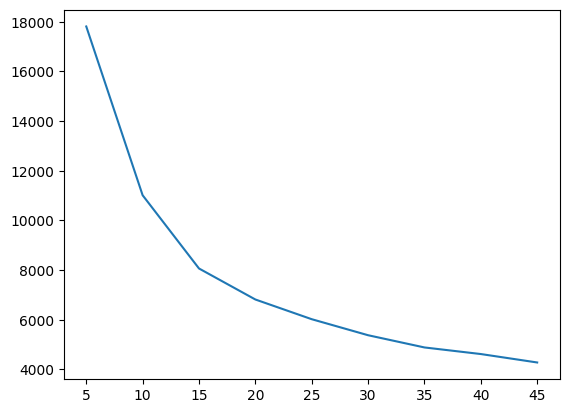

In [785]:
plt.plot(range(5, 50, 5), wcss)
plt.show()

In [786]:
kmeans = KMeans(n_clusters=35, random_state=42, n_init=10, max_iter=500)

In [787]:
kmeans.fit(scaled_clustering_data)

KMeans(max_iter=500, n_clusters=35, n_init=10, random_state=42)

In [788]:
X['cluster'] = kmeans.predict(scaled_clustering_data)

In [789]:
test_df['cluster'] = kmeans.predict(scaled_clustering_data_test)

In [790]:
X['mean_traffic_vol_cluster_wise'] = X.groupby(['cluster'])['Traffic_Vol'].transform('mean')
X['median_traffic_vol_cluster_wise'] = X.groupby(['cluster'])['Traffic_Vol'].transform('median')
X['std_traffic_vol_cluster_wise'] = X.groupby(['cluster'])['Traffic_Vol'].transform('std')

In [791]:
test_df['mean_traffic_vol_cluster_wise'] = X.groupby(['cluster'])['Traffic_Vol'].transform('mean')
test_df['median_traffic_vol_cluster_wise'] = X.groupby(['cluster'])['Traffic_Vol'].transform('median')
test_df['std_traffic_vol_cluster_wise'] = X.groupby(['cluster'])['Traffic_Vol'].transform('std')

In [792]:
X.drop(columns=['Traffic_Vol', 'Datetime', 'Weather', 'Weather_Desc'], inplace=True)

In [793]:
X.shape

(38373, 79)

In [794]:
test_df.drop(columns=['Datetime', 'Weather', 'Weather_Desc'], inplace=True)

## Model Training

In [795]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

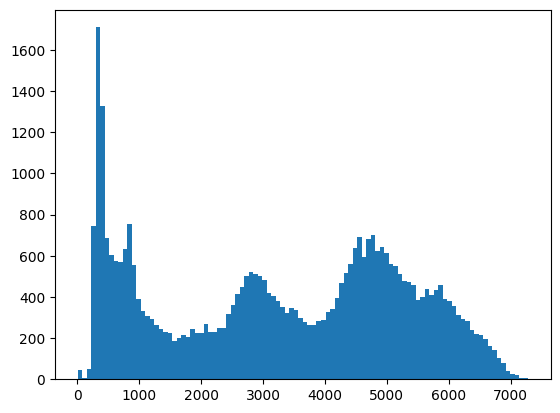

In [796]:
plt.hist(y, bins=100)
plt.show()

In [797]:
y[y==0].shape

(0,)

In [798]:
y = np.log1p(y)

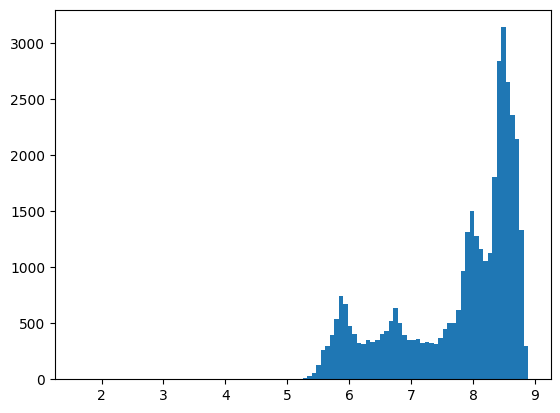

In [897]:
plt.hist(y, bins=100)
plt.show()

In [898]:
y[y<=0].shape

(0,)

In [799]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=False)

In [825]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=1, max_depth=15, max_features='sqrt', min_samples_split=5, min_samples_leaf=5)

In [826]:
rf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.3s finished


RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=5,
                      min_samples_split=5, n_jobs=-1, random_state=42,
                      verbose=1)

In [827]:
from sklearn.metrics import root_mean_squared_error

In [828]:
root_mean_squared_error(np.expm1(y_val), np.expm1(rf.predict(X_val)))

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.0s finished


np.float64(768.3495884516404)

In [829]:
root_mean_squared_error(np.expm1(y_train), np.expm1(rf.predict(X_train)))

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.1s finished


np.float64(649.8137139406384)

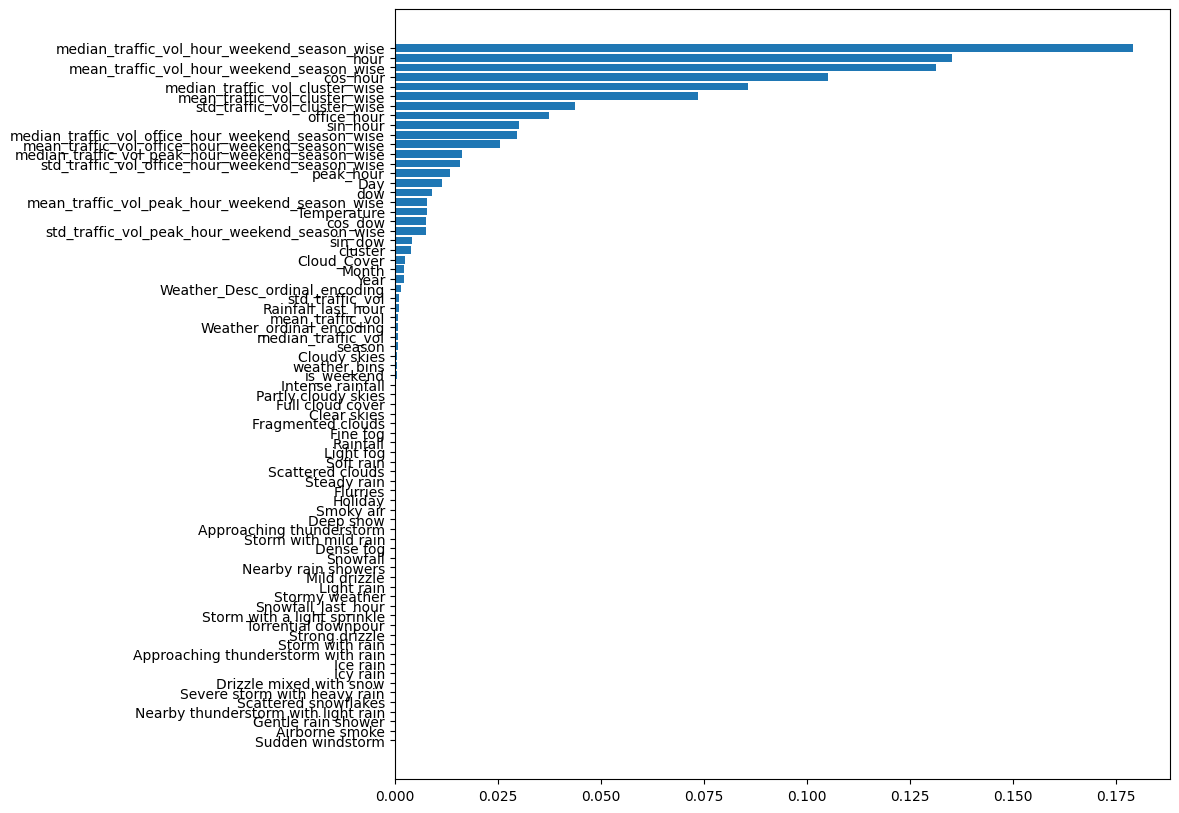

In [830]:
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
feature_importances = feature_importances.sort_values(by='importance', ascending=True)
plt.figure(figsize=(10, 10))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.show()


In [831]:
test_df.head()

,Holiday,Temperature,Rainfall_last_hour,Snowfall_last_hour,Cloud_Cover,Traffic_Vol,Year,Month,hour,Day,...,mean_traffic_vol_peak_hour_weekend_season_wise,median_traffic_vol_peak_hour_weekend_season_wise,std_traffic_vol_peak_hour_weekend_season_wise,mean_traffic_vol_office_hour_weekend_season_wise,median_traffic_vol_office_hour_weekend_season_wise,std_traffic_vol_office_hour_weekend_season_wise,cluster,mean_traffic_vol_cluster_wise,median_traffic_vol_cluster_wise,std_traffic_vol_cluster_wise
0,0.0,297.65,0.0,0,1,NaN,2014,1,0,7,...,5196.131024,5380.5,1170.652061,5068.487512,5039.0,847.551011,23,5366.770769,5533.0,1085.657822
1,0.0,297.45,0.0,0,1,NaN,2014,1,1,7,...,2878.538575,2833.0,1900.517147,5068.487512,5039.0,847.551011,23,4864.111621,4902.0,709.563937
2,0.0,296.75,0.0,0,1,NaN,2014,1,2,7,...,2878.538575,2833.0,1900.517147,5068.487512,5039.0,847.551011,27,4864.111621,4902.0,709.563937
3,0.0,296.42,0.0,0,1,NaN,2014,1,3,7,...,2878.538575,2833.0,1900.517147,5068.487512,5039.0,847.551011,27,4864.111621,4902.0,709.563937
4,0.0,295.56,0.0,0,40,NaN,2014,1,4,7,...,2878.538575,2833.0,1900.517147,5068.487512,5039.0,847.551011,27,4864.111621,4902.0,709.563937


In [838]:
X_train = X_train.drop(columns=list(weather_desc_encoded.columns))
X_val = X_val.drop(columns=list(weather_desc_encoded.columns))

In [839]:
test_df = test_df.drop(columns=list(weather_desc_encoded_test.columns))

In [834]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=1, max_depth=15, max_features='sqrt', min_samples_split=5, min_samples_leaf=5)

In [840]:
new_X = pd.concat([X_train, X_val], axis=0, ignore_index=True)
new_y = pd.concat([y_train, y_val], axis=0, ignore_index=True)

In [843]:
rf.fit(new_X, new_y)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.4s finished


RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=5,
                      min_samples_split=5, n_jobs=-1, random_state=42,
                      verbose=1)

In [844]:
test_df['Traffic_Vol'] = np.expm1(rf.predict(test_df.drop(columns=['Traffic_Vol'])))

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.0s finished


In [845]:
test_df

,Holiday,Temperature,Rainfall_last_hour,Snowfall_last_hour,Cloud_Cover,Traffic_Vol,Year,Month,hour,Day,...,mean_traffic_vol_peak_hour_weekend_season_wise,median_traffic_vol_peak_hour_weekend_season_wise,std_traffic_vol_peak_hour_weekend_season_wise,mean_traffic_vol_office_hour_weekend_season_wise,median_traffic_vol_office_hour_weekend_season_wise,std_traffic_vol_office_hour_weekend_season_wise,cluster,mean_traffic_vol_cluster_wise,median_traffic_vol_cluster_wise,std_traffic_vol_cluster_wise
0,0.0,297.65,0.0,0,1,3138.823928,2014,1,0,7,...,5196.131024,5380.5,1170.652061,5068.487512,5039.0,847.551011,23,5366.770769,5533.0,1085.657822
1,0.0,297.45,0.0,0,1,3048.370269,2014,1,1,7,...,2878.538575,2833.0,1900.517147,5068.487512,5039.0,847.551011,23,4864.111621,4902.0,709.563937
2,0.0,296.75,0.0,0,1,3024.663138,2014,1,2,7,...,2878.538575,2833.0,1900.517147,5068.487512,5039.0,847.551011,27,4864.111621,4902.0,709.563937
3,0.0,296.42,0.0,0,1,3177.067038,2014,1,3,7,...,2878.538575,2833.0,1900.517147,5068.487512,5039.0,847.551011,27,4864.111621,4902.0,709.563937
4,0.0,295.56,0.0,0,40,3212.504283,2014,1,4,7,...,2878.538575,2833.0,1900.517147,5068.487512,5039.0,847.551011,27,4864.111621,4902.0,709.563937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2203,0.0,283.85,0.0,0,75,4131.482111,2014,9,19,30,...,2727.125967,2744.0,1832.260807,4791.845154,4781.0,924.021694,4,4845.317323,4830.5,605.091391
2204,0.0,283.06,0.0,0,90,3964.387867,2014,9,20,30,...,2727.125967,2744.0,1832.260807,4791.845154,4781.0,924.021694,4,4845.317323,4830.5,605.091391
2205,0.0,282.93,0.0,0,90,3836.270300,2014,9,21,30,...,2727.125967,2744.0,1832.260807,4791.845154,4781.0,924.021694,4,4845.317323,4830.5,605.091391
2206,0.0,282.79,0.0,0,90,3893.633622,2014,9,22,30,...,2727.125967,2744.0,1832.260807,4791.845154,4781.0,924.021694,4,4845.317323,4830.5,605.091391


In [848]:
import xgboost as xgb

In [903]:
xgb_reg = xgb.XGBRegressor(n_estimators=1000, random_state=42, n_jobs=-1, max_depth=20, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1)

In [904]:
xgb_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=20, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [905]:
root_mean_squared_error(np.expm1(y_val), np.expm1(xgb_reg.predict(X_val)))

np.float64(770.1087478844851)

In [906]:
root_mean_squared_error(np.expm1(y_train), np.expm1(xgb_reg.predict(X_train)))

np.float64(20.849399733951657)

In [907]:
xgb_reg.fit(new_X, new_y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=20, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [908]:
test_df['Traffic_Vol'] = np.expm1(xgb_reg.predict(test_df.drop(columns=['Traffic_Vol'])))

In [909]:
test_df['Traffic_Vol'].to_csv("Dataset/Submission.csv", index=False)

In [910]:
min_vol = train_df['Traffic_Vol'].min()
max_vol = train_df['Traffic_Vol'].max()

In [911]:
min_vol, max_vol

(np.int64(4), np.int64(7289))

In [912]:
min_pred = test_df['Traffic_Vol'].min()
max_pred = test_df['Traffic_Vol'].max()

In [913]:
min_pred, max_pred

(np.float32(294.58902), np.float32(6538.2))